# LAB-P0: Introducción a los sistemas dinámicos computacionales

- **ID de práctica:** LAB-P0-v1.0
- **Capítulo del libro:** Cap. 1 — *An introduction to computational dynamic systems* (Bongers, Gómez y Torres, 2019)
- **Autores:** Antonio F. Romero Carrasco, Anelí Bongers
- **Fecha:** 2026-06-17
- **Versión:** 1.0
- **Licencia:** CC BY-SA 4.0 (este notebook) / MIT (el código de `macroaicomp`)

Modelo de carrera de armamentos de Richardson: un sistema dinámico lineal de
dos ecuaciones que sirve de introducción a los conceptos de estado
estacionario, autovalores y estabilidad antes de abordar modelos
macroeconómicos concretos (IS-LM, Dornbusch, DGE...).

> **👋 BIENVENIDA A LA PRÁCTICA - LEER ANTES DE EMPEZAR**
> 
> *   **¿Nunca has usado Jupyter?** No te preocupes. Este cuaderno es interactivo. Haz clic en cualquier celda de código y pulsa **`Shift + Enter`** para ejecutarla. Ve de arriba a abajo en orden.
> *   **¿Se ha congelado o sale un asterisco `[*]` eterno?** Ve al menú superior y dale a `Kernel` ➔ `Restart`.
> *   **El objetivo** de esta práctica es que juegues con la economía. Cambia los números del código que representan impuestos, dinero o tecnología, vuelve a ejecutar y mira los gráficos. ¡No puedes romper nada!
>

### 🕹️ GUÍA RÁPIDA PARA DUMMIES - Sistemas Dinámicos
*   **¿Qué estamos haciendo aquí?** Estamos estudiando cómo una variable cambia a lo largo del tiempo usando reglas matemáticas sencillas. Imagina que es el crecimiento de una población o el saldo de tu cuenta bancaria.
*   **Puntos de Equilibrio (Estado Estacionario):** Es el valor donde la variable se queda quieta (no sube ni baja).
*   **Estabilidad:** Si perturbas el sistema (le das un empujón), ¿vuelve al equilibrio (estable) o se dispara al infinito (inestable)?
*   **¡Prueba esto!** Busca donde se definen las matrices o ecuaciones, ejecuta las celdas con `Shift + Enter` y observa cómo las flechas del diagrama de fases te indican hacia dónde viaja el sistema.


In [1]:
%%capture
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # TODO: cuando el repo esté publicado en GitHub, sustituir por
    # %pip install git+https://github.com/<org>/macro-ai-comp.git
    %pip install numpy scipy matplotlib ipywidgets

In [2]:
# Standard library
from dataclasses import asdict

# Third-party
import numpy as np
from ipywidgets import interact, FloatSlider

# Proyecto (requiere `pip install -e .` desde la raíz del repo)
from macroaicomp.models.arms_race import (
    ArmsRaceParams,
    coefficient_matrices,
    eigenvalues,
    is_saddle_path,
    simulate,
    simulate_saddle_path,
    steady_state,
)
from macroaicomp.plotting.phase_diagram import plot_irf, plot_phase_diagram

## 1. Teoría

El modelo se escribe como un sistema dinámico lineal de dos variables
endógenas (ecs. 1.7-1.11 del libro):

$$
\begin{bmatrix} \Delta x_{1,t} \\ \Delta x_{2,t} \end{bmatrix}
= \underbrace{\begin{bmatrix} -\alpha & \beta \\ \gamma & -\delta \end{bmatrix}}_{A}
\begin{bmatrix} x_{1,t} \\ x_{2,t} \end{bmatrix}
+ \underbrace{\begin{bmatrix} \theta & 0 \\ 0 & \eta \end{bmatrix}}_{B}
\begin{bmatrix} z_{1,t} \\ z_{2,t} \end{bmatrix}
$$

donde $x_{1,t}$ y $x_{2,t}$ son el stock de armamento de los países 1 y 2.
El **estado estacionario** es $\bar{\mathbf{x}} = -A^{-1}B\mathbf{z}$ (ec. 1.14),
y la **estabilidad** depende de los autovalores de $A$: el sistema es
globalmente estable si $|\lambda_i + 1| < 1$ para ambos autovalores, y
presenta un **punto de silla** si solo uno de los dos cumple esa condición
(Apéndice A).

## 2. Calibración — Caso 1: estabilidad global (Tablas 1.1 y 1.2)

In [3]:
# Calibración del Caso 1: estabilidad global (Tabla 1.1 y 1.2 del libro)
params_global = ArmsRaceParams(
    alpha=0.50,  # sensibilidad de Delta x1 a su propio nivel x1
    beta=0.25,   # reacción de Delta x1 al stock de armamento x2
    gamma=0.25,  # reacción de Delta x2 al stock de armamento x1
    delta=0.50,  # sensibilidad de Delta x2 a su propio nivel x2
    theta=1.00,  # impacto de la variable exógena z1 sobre Delta x1
    eta=1.00,    # impacto de la variable exógena z2 sobre Delta x2
)
z_initial = np.array([1.0, 1.0])

asdict(params_global)

{'alpha': 0.5,
 'beta': 0.25,
 'gamma': 0.25,
 'delta': 0.5,
 'theta': 1.0,
 'eta': 1.0}

## 3. Resolución: estado estacionario y estabilidad

In [4]:
x_bar = steady_state(params_global, z_initial)
lambdas = eigenvalues(params_global)

print(f"Estado estacionario (x1_bar, x2_bar) = {x_bar.round(2)}")
print(f"Autovalores (lambda1, lambda2)        = {np.round(sorted(lambdas), 2)}")
print(f"Moduli |lambda + 1|                   = {np.round(np.abs(np.sort(lambdas) + 1), 2)}")
print(f"Punto de silla                        = {is_saddle_path(params_global)}")

Estado estacionario (x1_bar, x2_bar) = [4. 4.]
Autovalores (lambda1, lambda2)        = [-0.75 -0.25]
Moduli |lambda + 1|                   = [0.25 0.75]
Punto de silla                        = False


## 4. Verificación frente al oráculo

Comparamos contra los valores reportados en el libro y reproducidos por el
código MATLAB del Apéndice B (`referencia/m1.m`), recogidos en
`oraculo.md`: estado estacionario $(4, 4)$ y autovalores $(-0.25, -0.75)$.

In [5]:
np.testing.assert_allclose(x_bar, [4.0, 4.0], atol=1e-6)
np.testing.assert_allclose(sorted(lambdas), [-0.75, -0.25], atol=1e-6)
print("OK: coincide con el oráculo MATLAB (Apéndice B).")

OK: coincide con el oráculo MATLAB (Apéndice B).


## 5. Análisis de shock (Sección 1.5)

Aumentamos la variable exógena $z_1$ de 1 a 2 y observamos la transición
hacia el nuevo estado estacionario.

Nuevo estado estacionario (x1_bar, x2_bar) = (6.67, 5.33)  (esperado: 6.67, 5.33)


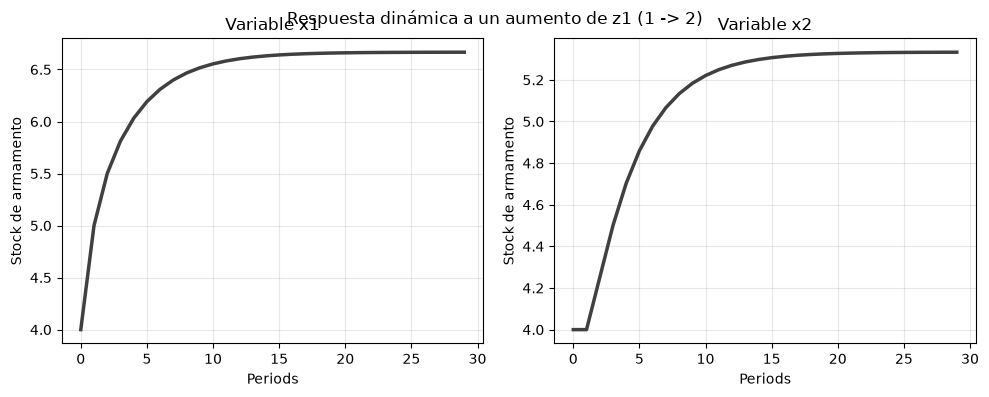

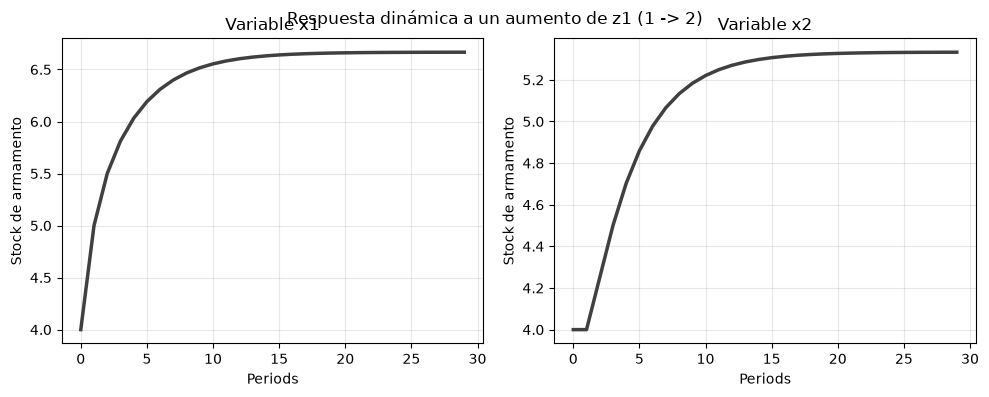

In [6]:
z_final_shock = np.array([2.0, 1.0])
x1_path, x2_path = simulate(params_global, z_initial, z_final_shock, periods=30)

print(f"Nuevo estado estacionario (x1_bar, x2_bar) = "
      f"({x1_path[-1]:.2f}, {x2_path[-1]:.2f})  (esperado: 6.67, 5.33)")

fig = plot_irf(x1_path, x2_path, ylabel="Stock de armamento")
fig.suptitle("Respuesta dinámica a un aumento de z1 (1 -> 2)")
fig

## 6. Diagrama de fases (Figura B.1 del Apéndice B)

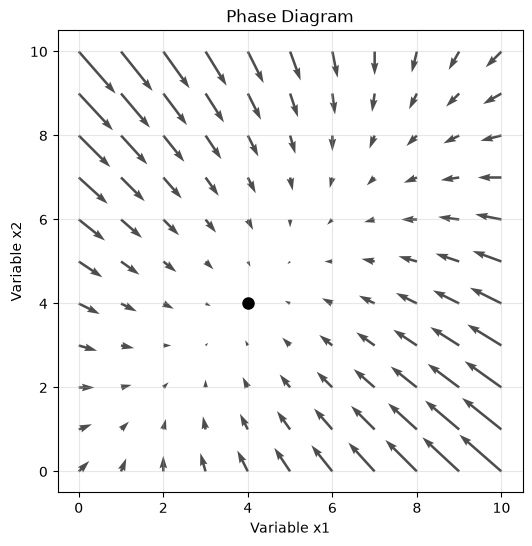

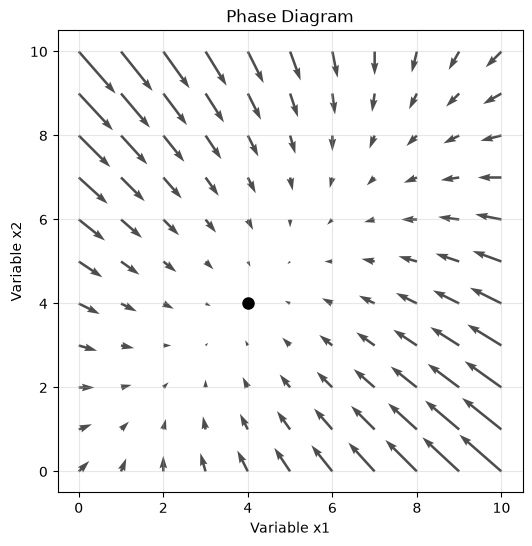

In [7]:
a, b = coefficient_matrices(params_global)
fig = plot_phase_diagram(a, b, z_initial, steady_state_point=x_bar, labels=("x1", "x2"))
fig

## 7. Análisis de sensibilidad (Sección 1.6.1)

Aumentamos $\alpha$ de 0.50 a 0.70: el país 1 se vuelve más sensible a su
propio stock de armamento, lo que reduce el estado estacionario de ambos
países y rompe la simetría entre ellos.

In [8]:
params_sensitivity = ArmsRaceParams(
    alpha=0.70, beta=0.25, gamma=0.25, delta=0.50, theta=1.00, eta=1.00
)
x_bar_sensitivity = steady_state(params_sensitivity, z_initial)
lambdas_sensitivity = eigenvalues(params_sensitivity)

print(f"Estado estacionario (x1_bar, x2_bar) = {x_bar_sensitivity.round(2)} "
      f"(esperado: 2.61, 3.30)")
print(f"Autovalores                          = {np.round(sorted(lambdas_sensitivity), 2)} "
      f"(esperado: -0.87, -0.33)")
print(f"Punto de silla                       = {is_saddle_path(params_sensitivity)} "
      f"(esperado: False, sigue siendo estable)")

np.testing.assert_allclose(x_bar_sensitivity, [2.61, 3.30], atol=1e-2)
np.testing.assert_allclose(sorted(lambdas_sensitivity), [-0.87, -0.33], atol=1e-2)

Estado estacionario (x1_bar, x2_bar) = [2.61 3.3 ] (esperado: 2.61, 3.30)
Autovalores                          = [-0.87 -0.33] (esperado: -0.87, -0.33)
Punto de silla                       = False (esperado: False, sigue siendo estable)


## 8. Punto de silla (Sección 1.6.2)

Con $\beta, \gamma > \alpha, \delta$ (Tabla 1.3) el sistema tiene un
autovalor estable y otro inestable: el estado estacionario es un punto de
silla. La variable $x_1$ se asume "de salto" (forward-looking) y se
reajusta instantáneamente sobre la senda estable ante una perturbación
(ec. 1.39), mientras $x_2$ evoluciona de forma estándar.

Punto de silla = True (esperado: True)
Salto instantáneo de x1 en el periodo del shock = 2.00 (esperado: 2.00)
Nuevo estado estacionario (x1, x2) = (3.33, 2.67)  (esperado: 3.33, 2.67)


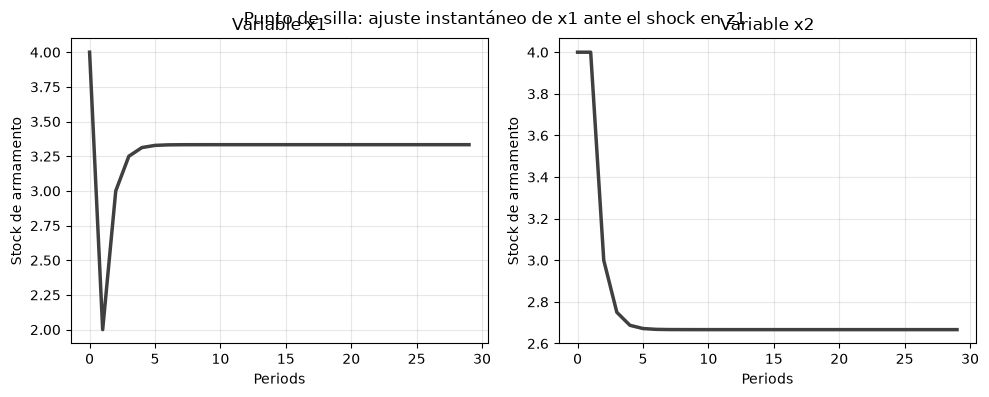

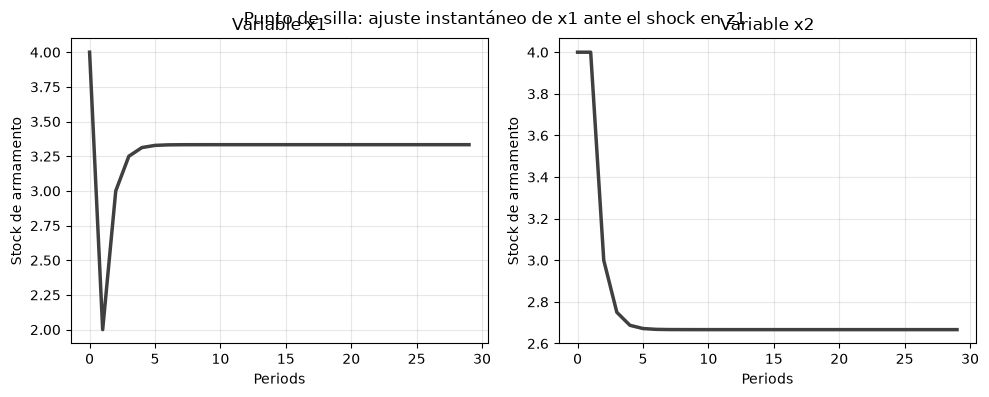

In [9]:
params_saddle = ArmsRaceParams(
    alpha=0.25, beta=0.50, gamma=0.50, delta=0.25, theta=1.00, eta=1.00
)
z_initial_saddle = np.array([-1.0, -1.0])
z_final_saddle = np.array([-0.5, -1.0])

print(f"Punto de silla = {is_saddle_path(params_saddle)} (esperado: True)")

x1_saddle, x2_saddle = simulate_saddle_path(
    params_saddle, z_initial_saddle, z_final_saddle, periods=30, jump_variable=0
)

print(f"Salto instantáneo de x1 en el periodo del shock = {x1_saddle[1]:.2f} (esperado: 2.00)")
print(f"Nuevo estado estacionario (x1, x2) = "
      f"({x1_saddle[-1]:.2f}, {x2_saddle[-1]:.2f})  (esperado: 3.33, 2.67)")

np.testing.assert_allclose(x1_saddle[1], 2.0, atol=1e-2)
np.testing.assert_allclose([x1_saddle[-1], x2_saddle[-1]], [3.33, 2.67], atol=1e-2)

fig = plot_irf(x1_saddle, x2_saddle, ylabel="Stock de armamento")
fig.suptitle("Punto de silla: ajuste instantáneo de x1 ante el shock en z1")
fig

## 9. Widget interactivo — sensibilidad al shock de z1

Mueve el slider para comprobar cómo cambia la trayectoria de ambas
variables según la magnitud del shock sobre $z_1$ (calibración de
estabilidad global, Caso 1).

In [10]:
def _plot_shock(z1_final: float = 2.0):
    x1_path, x2_path = simulate(params_global, z_initial, np.array([z1_final, 1.0]), periods=30)
    fig = plot_irf(x1_path, x2_path, ylabel="Stock de armamento")
    fig.suptitle(f"Shock z1: 1 -> {z1_final:.2f}")


interact(_plot_shock, z1_final=FloatSlider(value=2.0, min=-2.0, max=4.0, step=0.25));

interactive(children=(FloatSlider(value=2.0, description='z1_final', max=4.0, min=-2.0, step=0.25), Output()),…

## 10. Buenas prácticas aplicadas aquí

Observa que `steady_state()`, `eigenvalues()`, `simulate()` y
`simulate_saddle_path()` están documentadas con docstrings NumPy, tienen
type hints y viven en `src/macroaicomp/models/arms_race.py` — no en este
notebook. La lógica del modelo está separada de la visualización
(`src/macroaicomp/plotting/phase_diagram.py`). Cuando hagas tu ABP, haz lo
mismo: funciones reutilizables a `src/`, el notebook solo para exponer y
narrar el análisis.

## 11. Conclusión

El mismo sistema dinámico lineal puede mostrar dos comportamientos
cualitativamente distintos según el valor de sus parámetros: estabilidad
global, donde toda perturbación converge suavemente al nuevo equilibrio, o
un punto de silla, donde una variable debe "saltar" instantáneamente para
mantener la convergencia. Esta distinción —y el procedimiento para
detectarla a partir de los autovalores de $A$— es la base que reutilizaremos
en el resto de prácticas (IS-LM dinámico, Dornbusch, DGE) cuando los
sistemas dejen de ser ejemplos genéricos y representen economías reales.
Los resultados numéricos coinciden exactamente con el oráculo MATLAB del
Apéndice B, lo que valida el port a Python.